In [3]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [4]:
df_AUZ = df[df['job_country'] == 'Australia'].copy()
df_AUZ['job_posted_month'] = df_AUZ['job_posted_date'].dt.strftime('%B')

df_AUZ_piovt = df_AUZ.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

df_AUZ_piovt.reset_index(inplace=True)
df_AUZ_piovt['month_number'] = pd.to_datetime(df_AUZ_piovt['job_posted_month'], format='%B').dt.month

df_AUZ_piovt.sort_values('month_number', inplace=True)
df_AUZ_piovt.set_index('job_posted_month', inplace=True)
df_AUZ_piovt.drop(columns='month_number', inplace=True)

top_3 = df_AUZ['job_title_short'].value_counts().head(3)
top_3 = top_3.index.to_list()

'''df_AUZ_piovt[top_3].plot(kind='line')
plt.title('Monthly Job Posting for Top Data Jobs in Australia')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.legend()
plt.show()'''

"df_AUZ_piovt[top_3].plot(kind='line')\nplt.title('Monthly Job Posting for Top Data Jobs in Australia')\nplt.xlabel('2023')\nplt.ylabel('Job Count')\nplt.legend()\nplt.show()"

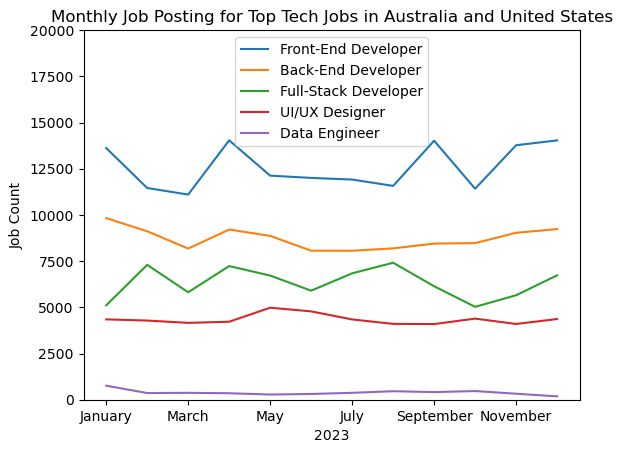

In [18]:
df_US_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col='job_posted_month')
df_AUZ_US_merged = df_AUZ_piovt.merge(df_US_software_pivot, on='job_posted_month')

top5 = (df_AUZ_US_merged
        .sum()
        .sort_values(ascending=False)
        .head()
        .index
        .to_list())
df_AUZ_US_merged[top5].plot(kind='line')
plt.title('Monthly Job Posting for Top Tech Jobs in Australia and United States')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.ylim(0, 20000)
plt.legend()
plt.show()